# Tarea N°1 — Inteligencia Artificial
## Parte 1: Aprendizaje de Estructura de Red Bayesiana

**Dataset:** Adult Income (UCI Census Income Dataset)  
**Librería principal:** pgmpy  

### Descripción del dataset
El dataset Adult Income contiene aproximadamente 48.000 registros del censo de EE.UU. con características sociodemográficas de individuos. El objetivo original es predecir si el ingreso anual de una persona supera los 50.000 USD. Tiene más de 14 columnas, de las cuales seleccionaremos 7 variables útiles para construir la red bayesiana.

## 1. Carga y Preprocesamiento del Dataset

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


df_raw = pd.read_csv('adult.csv')

# Renombrar columnas al formato esperado
df_raw.columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

print(f"Dimensiones originales: {df_raw.shape}")
df_raw.head()

Dimensiones originales: (32561, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [61]:
# Reemplazar '?' por NaN y eliminar filas con valores faltantes
df_raw.replace('?', np.nan, inplace=True)
df_raw.dropna(inplace=True)
print(f"Dimensiones tras limpiar NaN: {df_raw.shape}")

# Selección de 7 variables útiles
variables = ['age', 'education_num', 'occupation', 'workclass', 'hours_per_week', 'sex', 'income']
df = df_raw[variables].copy()

print("\nDistribución de tipos:")
print(df.dtypes)
print(f"\nFilas totales: {len(df)}")

Dimensiones tras limpiar NaN: (30162, 15)

Distribución de tipos:
age               int64
education_num     int64
occupation          str
workclass           str
hours_per_week    int64
sex                 str
income              str
dtype: object

Filas totales: 30162


In [62]:
# Discretización de variables continuas

# age -> joven (<=30), adulto (31-50), mayor (>50)
df['age'] = pd.cut(df['age'], bins=[0, 30, 50, 100],
                   labels=['joven', 'adulto', 'mayor'])

# education_num -> bajo (<=8), medio (9-12), alto (>12)
df['education_num'] = pd.cut(df['education_num'], bins=[0, 8, 12, 20],
                              labels=['bajo', 'medio', 'alto'])

# hours_per_week -> part_time (<40), full_time (40), overtime (>40)
df['hours_per_week'] = pd.cut(df['hours_per_week'], bins=[0, 39, 40, 100],
                               labels=['part_time', 'full_time', 'overtime'])

# Simplificar workclass a 3 categorías
def simplify_workclass(w):
    if w in ['Private']:
        return 'Privado'
    elif w in ['Self-emp-not-inc', 'Self-emp-inc']:
        return 'Independiente'
    else:
        return 'Gobierno_Otro'

df['workclass'] = df['workclass'].apply(simplify_workclass)

# Simplificar occupation a 4 grupos
def simplify_occupation(o):
    manual = ['Craft-repair', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Transport-moving']
    white  = ['Adm-clerical', 'Exec-managerial', 'Prof-specialty', 'Sales', 'Tech-support']
    service= ['Other-service', 'Priv-house-serv', 'Protective-serv']
    if o in manual:
        return 'Manual'
    elif o in white:
        return 'Oficina'
    elif o in service:
        return 'Servicio'
    else:
        return 'Otro'

df['occupation'] = df['occupation'].apply(simplify_occupation)

# Limpiar income
df['income'] = df['income'].str.strip().str.replace('.', '', regex=False)
df['income'] = df['income'].map({'<=50K': 'bajo', '>50K': 'alto'})

# Convertir todo a string para pgmpy
df = df.astype(str)

print("\n--- Dataset preprocesado ---")
print(df.head(10))
print(f"\nDimensiones finales: {df.shape}")


--- Dataset preprocesado ---
       age education_num occupation      workclass hours_per_week     sex  \
1    mayor         medio    Oficina        Privado      part_time  Female   
3    mayor          bajo     Manual        Privado      full_time  Female   
4   adulto         medio    Oficina        Privado      full_time  Female   
5   adulto         medio   Servicio        Privado       overtime  Female   
6   adulto          bajo    Oficina        Privado      full_time    Male   
7    mayor          alto    Oficina  Gobierno_Otro      part_time  Female   
8    mayor         medio    Oficina  Gobierno_Otro      full_time  Female   
10  adulto          alto    Oficina        Privado      part_time  Female   
11  adulto          alto    Oficina  Independiente       overtime    Male   
12   mayor          alto   Servicio        Privado      part_time  Female   

   income  
1    bajo  
3    bajo  
4    bajo  
5    bajo  
6    bajo  
7    alto  
8    bajo  
10   alto  
11   alto  
12

In [63]:
# Verificar cardinalidades
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

age: <StringArray>
['mayor', 'adulto', 'joven']
Length: 3, dtype: str
education_num: <StringArray>
['medio', 'bajo', 'alto']
Length: 3, dtype: str
occupation: <StringArray>
['Oficina', 'Manual', 'Servicio', 'Otro']
Length: 4, dtype: str
workclass: <StringArray>
['Privado', 'Gobierno_Otro', 'Independiente']
Length: 3, dtype: str
hours_per_week: <StringArray>
['part_time', 'full_time', 'overtime']
Length: 3, dtype: str
sex: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
income: <StringArray>
['bajo', 'alto']
Length: 2, dtype: str


## 2. Aprendizaje de Estructura

### 2.1 Método Hill-Climbing

Hill-Climbing es un algoritmo de búsqueda local heurística. Parte de un grafo vacío y en cada iteración evalúa tres tipos de operaciones sobre los arcos del grafo dirigido:

- **Agregar** un arco entre dos nodos
- **Eliminar** un arco existente
- **Revertir** la dirección de un arco

Cada operación es evaluada mediante una función de puntuación. Se elige la operación que más mejora el puntaje. El proceso se repite hasta que ninguna operación mejore el puntaje actual (convergencia local).

**Ventajas:** Escalable a datasets grandes.  
**Desventajas:** Puede quedar atrapado en óptimos locales.

In [64]:
from pgmpy.estimators import HillClimbSearch, BDeu, BIC, K2
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator
from pgmpy.inference import VariableElimination

# Aprendizaje de estructura con Hill-Climbing
scoring_method = BIC(df)
hc = HillClimbSearch(df)

print("Ejecutando Hill-Climbing...")
best_model_hc = hc.estimate(scoring_method=scoring_method, max_iter=1000)

print("\n--- Estructura aprendida por Hill-Climbing ---")
print("Arcos encontrados:")
for edge in best_model_hc.edges():
    print(f"  {edge[0]} -> {edge[1]}")

Ejecutando Hill-Climbing...


  2%|▏         | 19/1000 [00:00<00:33, 29.36it/s]


--- Estructura aprendida por Hill-Climbing ---
Arcos encontrados:
  education_num -> occupation
  education_num -> age
  occupation -> workclass
  workclass -> age
  hours_per_week -> age
  hours_per_week -> income
  hours_per_week -> workclass
  hours_per_week -> occupation
  hours_per_week -> education_num
  sex -> occupation
  sex -> hours_per_week
  sex -> income
  sex -> education_num
  sex -> workclass
  income -> education_num
  income -> age
  income -> occupation


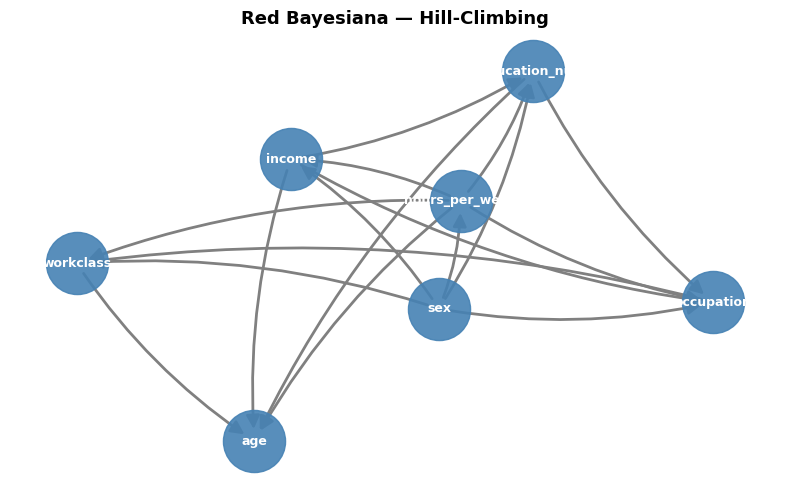

In [65]:
import networkx as nx

def plot_bn(edges, title):
    G = nx.DiGraph()
    G.add_edges_from(edges)
    pos = nx.spring_layout(G, seed=42, k=2)
    plt.figure(figsize=(8, 5))
    nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='steelblue', alpha=0.9)
    nx.draw_networkx_labels(G, pos, font_color='white', font_size=9, font_weight='bold')
    nx.draw_networkx_edges(G, pos, arrowsize=20, edge_color='gray',
                           connectionstyle='arc3,rad=0.1', width=2)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

plot_bn(best_model_hc.edges(), "Red Bayesiana — Hill-Climbing")

### 2.2 Búsqueda Exhaustiva 


La búsqueda exhaustiva evalúa todos los DAGs (grafos dirigidos acíclicos) posibles sobre el conjunto de variables, calculando la puntuación de cada uno y retornando el de mayor puntaje. Garantiza encontrar el óptimo global.

**Limitación:** El número de DAGs posibles crece muy exponencialmente con el número de nodos. Con $n$ variables, el número de DAGs sigue la secuencia OEIS A003024:  
- 4 nodos → 543 DAGs  
- 5 nodos → 29.281 DAGs  
- 7 nodos → ~2.000.000 DAGs  

Por esta razón, aplicaremos búsqueda exhaustiva solo sobre un subconjunto de **4–5 variables** representativas, justificando la selección.

In [66]:
from pgmpy.estimators import ExhaustiveSearch

vars_exhaustive = ['education_num', 'occupation', 'hours_per_week', 'sex', 'income']
df_small = df[vars_exhaustive].copy()

print("Ejecutando Búsqueda Exhaustiva (puede tardar unos minutos)...")
es = ExhaustiveSearch(df_small, scoring_method=BIC(df_small))
best_model_ex = es.estimate()

print("\n--- Estructura aprendida por Búsqueda Exhaustiva ---")
print("Arcos encontrados:")
for edge in best_model_ex.edges():
    print(f"  {edge[0]} -> {edge[1]}")

Ejecutando Búsqueda Exhaustiva (puede tardar unos minutos)...

--- Estructura aprendida por Búsqueda Exhaustiva ---
Arcos encontrados:
  education_num -> hours_per_week
  education_num -> income
  education_num -> occupation
  hours_per_week -> income
  hours_per_week -> occupation
  hours_per_week -> sex
  income -> sex
  occupation -> income
  occupation -> sex


## Justificación de la reducción de variables:
 Con 7 variables la búsqueda exhaustiva requiere evaluar millones de DAGs, lo que es computacionalmente inviable en un entorno estándar. Seleccionamos las 5 variables con mayor relevancia para predecir 'income': education_num, occupation, hours_per_week, sex, income. Esto nos permite realizar la búsqueda exhaustiva en tiempo razonable y comparar la estructura obtenida con la de Hill-Climbing.

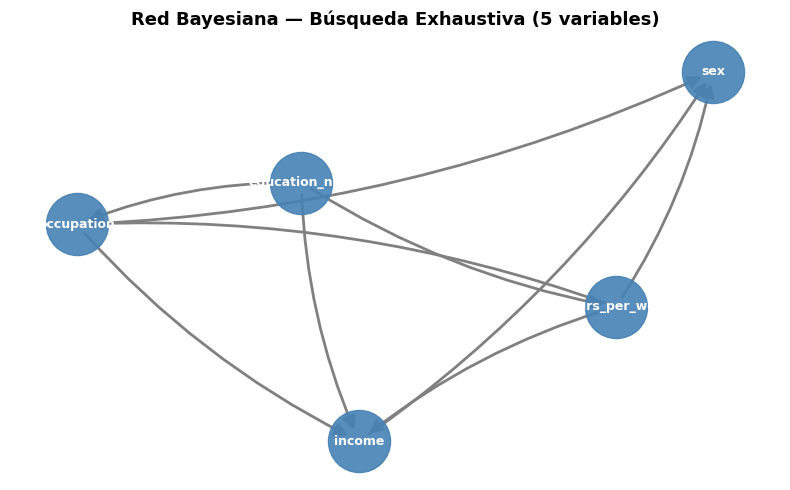

In [67]:
plot_bn(best_model_ex.edges(), "Red Bayesiana — Búsqueda Exhaustiva (5 variables)")

## 3. Estimación de Parámetros (CPDs)

Una vez definida la estructura, estimamos las Tablas de Probabilidad Condicional de cada nodo usando Maximum Likelihood Estimation (MLE). MLE estima cada probabilidad como la frecuencia relativa observada en los datos para cada combinación de valores padre-hijo.

In [68]:
from pgmpy.estimators import HillClimbSearch, BDeu, BIC, K2
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator
from pgmpy.inference import VariableElimination

# ---- Parámetros Red Hill-Climbing ----
model_hc = DiscreteBayesianNetwork(best_model_hc.edges())
model_hc.fit(df, estimator=MaximumLikelihoodEstimator)

print("=== Parámetros Red Hill-Climbing ===")
for cpd in model_hc.cpds:
    print(cpd)
    print()

=== Parámetros Red Hill-Climbing ===
+----------------------+-----+---------------------------+
| hours_per_week       | ... | hours_per_week(part_time) |
+----------------------+-----+---------------------------+
| income               | ... | income(bajo)              |
+----------------------+-----+---------------------------+
| sex                  | ... | sex(Male)                 |
+----------------------+-----+---------------------------+
| education_num(alto)  | ... | 0.1572304363505229        |
+----------------------+-----+---------------------------+
| education_num(bajo)  | ... | 0.23728813559322035       |
+----------------------+-----+---------------------------+
| education_num(medio) | ... | 0.6054814280562567        |
+----------------------+-----+---------------------------+

+----------------------+-----+---------------------------+
| education_num        | ... | education_num(medio)      |
+----------------------+-----+---------------------------+
| hours_per_week  

In [69]:
# ---- Parámetros Red Búsqueda Exhaustiva ----
model_ex = DiscreteBayesianNetwork(best_model_ex.edges())
model_ex.fit(df_small, estimator=MaximumLikelihoodEstimator)

print("=== Parámetros Red Búsqueda Exhaustiva ===")
for cpd in model_ex.cpds:
    print(cpd)
    print()

=== Parámetros Red Búsqueda Exhaustiva ===
+----------------------+----------+
| education_num(alto)  | 0.251575 |
+----------------------+----------+
| education_num(bajo)  | 0.12403  |
+----------------------+----------+
| education_num(medio) | 0.624395 |
+----------------------+----------+

+---------------------------+-----+----------------------+
| education_num             | ... | education_num(medio) |
+---------------------------+-----+----------------------+
| hours_per_week(full_time) | ... | 0.4979557160303722   |
+---------------------------+-----+----------------------+
| hours_per_week(overtime)  | ... | 0.27462432963415284  |
+---------------------------+-----+----------------------+
| hours_per_week(part_time) | ... | 0.22741995433547496  |
+---------------------------+-----+----------------------+

+----------------+-----+---------------------------+
| education_num  | ... | education_num(medio)      |
+----------------+-----+---------------------------+
| hours_per_w

## 4. Inferencias a Posteriori (Diagnóstico)

Usamos Variable Elimination para calcular probabilidades a posteriori dada evidencia observada.

### 4.1 Inferencias en Red Hill-Climbing

In [70]:
infer_hc = VariableElimination(model_hc)

# Inferencia 1: ¿Cuál es la probabilidad de ingreso alto dado que
# la persona tiene educación alta y trabaja en Oficina?
print("=== INFERENCIA HC 1 ===")
print("Consulta: P(income | education_num=alto, occupation=Oficina)")
q1_hc = infer_hc.query(
    variables=['income'],
    evidence={'education_num': 'alto', 'occupation': 'Oficina'}
)
print(q1_hc)
print("\nInterpretación: Dado que la persona tiene educación alta y trabaja en Oficina,",
      "la probabilidad de que su ingreso sea alto es:",
      round(q1_hc.values[list(q1_hc.state_names['income']).index('alto')], 4))

=== INFERENCIA HC 1 ===
Consulta: P(income | education_num=alto, occupation=Oficina)
+--------------+---------------+
| income       |   phi(income) |
+==============+===============+
| income(alto) |        0.5130 |
+--------------+---------------+
| income(bajo) |        0.4870 |
+--------------+---------------+

Interpretación: Dado que la persona tiene educación alta y trabaja en Oficina, la probabilidad de que su ingreso sea alto es: 0.513


In [71]:
# Inferencia 2: ¿Cuál es la distribución de educación dado que
# la persona tiene ingreso alto y hace overtime?
print("=== INFERENCIA HC 2 ===")
print("Consulta: P(education_num | income=alto, hours_per_week=overtime)")
q2_hc = infer_hc.query(
    variables=['education_num'],
    evidence={'income': 'alto', 'hours_per_week': 'overtime'}
)
print(q2_hc)
print("\nInterpretación: Entre quienes tienen ingreso alto y trabajan más de 40 horas,",
      "la distribución sobre el nivel de educación es la indicada arriba.")

=== INFERENCIA HC 2 ===
Consulta: P(education_num | income=alto, hours_per_week=overtime)
+----------------------+----------------------+
| education_num        |   phi(education_num) |
+======================+======================+
| education_num(alto)  |               0.5603 |
+----------------------+----------------------+
| education_num(bajo)  |               0.0238 |
+----------------------+----------------------+
| education_num(medio) |               0.4159 |
+----------------------+----------------------+

Interpretación: Entre quienes tienen ingreso alto y trabajan más de 40 horas, la distribución sobre el nivel de educación es la indicada arriba.


### 4.2 Inferencias en Red Búsqueda Exhaustiva

In [72]:
infer_ex = VariableElimination(model_ex)

# Inferencia 1: ¿Cuál es la probabilidad de ingreso dado que
# la persona es mujer y trabaja part_time?
print("=== INFERENCIA EX 1 ===")
print("Consulta: P(income | sex=Female, hours_per_week=part_time)")
q1_ex = infer_ex.query(
    variables=['income'],
    evidence={'sex': 'Female', 'hours_per_week': 'part_time'}
)
print(q1_ex)
print("\nInterpretación: Para una mujer que trabaja menos de 40 horas semanales,",
      "la probabilidad de tener ingreso bajo es:",
      round(q1_ex.values[list(q1_ex.state_names['income']).index('bajo')], 4))

=== INFERENCIA EX 1 ===
Consulta: P(income | sex=Female, hours_per_week=part_time)
+--------------+---------------+
| income       |   phi(income) |
+==============+===============+
| income(alto) |        0.0786 |
+--------------+---------------+
| income(bajo) |        0.9214 |
+--------------+---------------+

Interpretación: Para una mujer que trabaja menos de 40 horas semanales, la probabilidad de tener ingreso bajo es: 0.9214


In [73]:
# Inferencia 2: ¿Cuál es la distribución de ocupación dado que
# la persona tiene educación media e ingreso alto?
print("=== INFERENCIA EX 2 ===")
print("Consulta: P(occupation | education_num=medio, income=alto)")
q2_ex = infer_ex.query(
    variables=['occupation'],
    evidence={'education_num': 'medio', 'income': 'alto'}
)
print(q2_ex)
print("\nInterpretación: Entre las personas con educación media e ingreso alto,",
      "la distribución por tipo de ocupación es la indicada arriba.")

=== INFERENCIA EX 2 ===
Consulta: P(occupation | education_num=medio, income=alto)
+----------------------+-------------------+
| occupation           |   phi(occupation) |
+======================+===================+
| occupation(Manual)   |            0.3786 |
+----------------------+-------------------+
| occupation(Oficina)  |            0.5550 |
+----------------------+-------------------+
| occupation(Otro)     |            0.0000 |
+----------------------+-------------------+
| occupation(Servicio) |            0.0664 |
+----------------------+-------------------+

Interpretación: Entre las personas con educación media e ingreso alto, la distribución por tipo de ocupación es la indicada arriba.


## 5. Generación de Datos Sintéticos

Usamos el modelo Hill-Climbing (que usa las 7 variables completas) para generar muestras sintéticas que aumenten el dataset en un 10%, 20% y 40%.

In [74]:
n_original = len(df)
print(f"Tamaño original del dataset: {n_original}")

augmented_datasets = {}

for pct in [0.10, 0.20, 0.40]:
    n_synthetic = int(n_original * pct)
    print(f"\nGenerando {n_synthetic} filas sintéticas ({int(pct*100)}%)...")
    
    # Muestreo desde la red bayesiana ajustada
    df_synthetic = model_hc.simulate(n_samples=n_synthetic)
    
    # Concatenar con dataset original
    df_augmented = pd.concat([df, df_synthetic], ignore_index=True)
    augmented_datasets[pct] = df_augmented
    
    print(f"  Dataset aumentado al {int(pct*100)}%: {len(df_augmented)} filas")

Tamaño original del dataset: 30162

Generando 3016 filas sintéticas (10%)...


Generating for node: age: 100%|██████████| 7/7 [00:00<00:00, 108.97it/s]  


  Dataset aumentado al 10%: 33178 filas

Generando 6032 filas sintéticas (20%)...


Generating for node: age: 100%|██████████| 7/7 [00:00<00:00, 83.81it/s]   

  Dataset aumentado al 20%: 36194 filas

Generando 12064 filas sintéticas (40%)...



Generating for node: age: 100%|██████████| 7/7 [00:00<00:00, 58.22it/s]   


  Dataset aumentado al 40%: 42226 filas


## 6. Re-entrenamiento con Datasets Aumentados y Comparación

Para cada dataset aumentado, repetimos: aprendizaje de estructura (HC), estimación de parámetros e inferencias.

In [75]:
results = {}

for pct, df_aug in augmented_datasets.items():
    label = f"+{int(pct*100)}%"
    print(f"\n{'='*55}")
    print(f"  Procesando dataset aumentado {label} ({len(df_aug)} filas)")
    print(f"{'='*55}")
    
    # Aprendizaje de estructura
    hc_aug = HillClimbSearch(df_aug)
    model_aug = hc_aug.estimate(
        scoring_method=BIC(df_aug),
        max_iter=1000
    )
    
    print(f"\nArcos aprendidos ({label}):")
    for e in model_aug.edges():
        print(f"  {e[0]} -> {e[1]}")
    
    # Estimación de parámetros
    bn_aug = DiscreteBayesianNetwork(model_aug.edges())
    bn_aug.fit(df_aug, estimator=MaximumLikelihoodEstimator)
    
    # Inferencia equivalente a la del dataset original
    infer_aug = VariableElimination(bn_aug)
    
    try:
        q_aug = infer_aug.query(
            variables=['income'],
            evidence={'education_num': 'alto', 'occupation': 'Oficina'}
        )
        prob = round(q_aug.values[list(q_aug.state_names['income']).index('alto')], 4)
        print(f"  P(income=alto | education=alto, ocupacion=Oficina): {prob}")
    except Exception as ex:
        prob = None
        print(f"  Inferencia no disponible (arco no presente): {ex}")
    
    results[label] = {
        'n_filas': len(df_aug),
        'n_arcos': len(model_aug.edges()),
        'arcos': list(model_aug.edges()),
        'P_income_alto': prob
    }

# Dataset original
infer_orig = VariableElimination(model_hc)
q_orig = infer_orig.query(
    variables=['income'],
    evidence={'education_num': 'alto', 'occupation': 'Oficina'}
)
prob_orig = round(q_orig.values[list(q_orig.state_names['income']).index('alto')], 4)
results['Original'] = {
    'n_filas': n_original,
    'n_arcos': len(model_hc.edges()),
    'arcos': list(model_hc.edges()),
    'P_income_alto': prob_orig
}


  Procesando dataset aumentado +10% (33178 filas)


  2%|▏         | 18/1000 [00:00<00:29, 32.85it/s]



Arcos aprendidos (+10%):
  education_num -> income
  education_num -> age
  occupation -> education_num
  occupation -> workclass
  occupation -> income
  workclass -> age
  hours_per_week -> sex
  hours_per_week -> occupation
  hours_per_week -> age
  hours_per_week -> workclass
  hours_per_week -> education_num
  hours_per_week -> income
  sex -> occupation
  sex -> income
  sex -> education_num
  sex -> workclass
  income -> age
  P(income=alto | education=alto, ocupacion=Oficina): 0.5137

  Procesando dataset aumentado +20% (36194 filas)


  2%|▏         | 17/1000 [00:00<00:31, 31.43it/s]



Arcos aprendidos (+20%):
  age -> income
  age -> workclass
  age -> hours_per_week
  age -> education_num
  education_num -> occupation
  occupation -> workclass
  occupation -> sex
  workclass -> sex
  hours_per_week -> sex
  hours_per_week -> workclass
  hours_per_week -> occupation
  hours_per_week -> education_num
  income -> education_num
  income -> hours_per_week
  income -> sex
  income -> occupation
  P(income=alto | education=alto, ocupacion=Oficina): 0.5152

  Procesando dataset aumentado +40% (42226 filas)


  2%|▏         | 17/1000 [00:00<00:34, 28.84it/s]


Arcos aprendidos (+40%):
  education_num -> income
  education_num -> hours_per_week
  occupation -> education_num
  occupation -> workclass
  occupation -> hours_per_week
  occupation -> income
  workclass -> age
  hours_per_week -> workclass
  hours_per_week -> age
  sex -> occupation
  sex -> hours_per_week
  sex -> income
  sex -> education_num
  sex -> workclass
  income -> age
  income -> hours_per_week
  P(income=alto | education=alto, ocupacion=Oficina): 0.5111


In [76]:
# ---- Tabla comparativa ----
summary = pd.DataFrame(results).T[['n_filas', 'n_arcos', 'P_income_alto']]
summary.index.name = 'Dataset'
print("\n=== TABLA COMPARATIVA ===")
print(summary.to_string())


=== TABLA COMPARATIVA ===
         n_filas n_arcos P_income_alto
Dataset                               
+10%       33178      17        0.5137
+20%       36194      16        0.5152
+40%       42226      16        0.5111
Original   30162      17         0.513


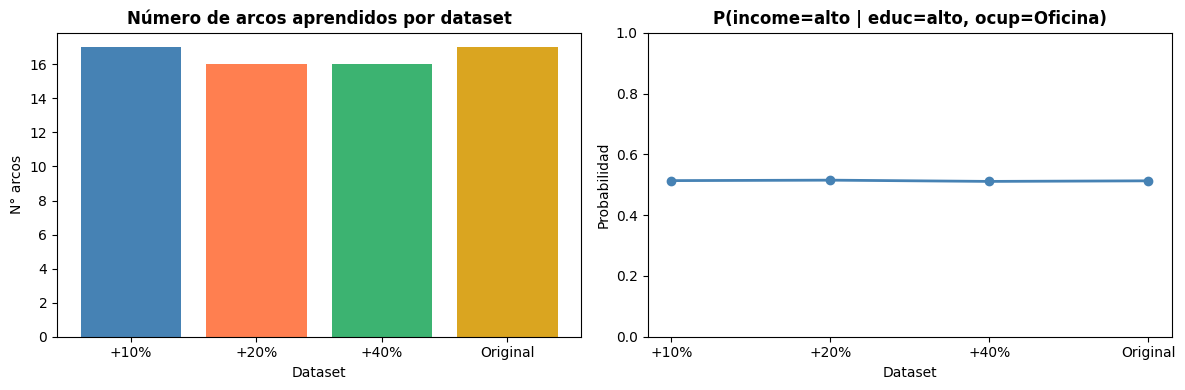

In [77]:
# ---- Gráfico comparativo ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = list(summary.index)
n_arcos = summary['n_arcos'].values.astype(int)
p_vals = summary['P_income_alto'].values.astype(float)

axes[0].bar(labels, n_arcos, color=['steelblue', 'coral', 'mediumseagreen', 'goldenrod'])
axes[0].set_title('Número de arcos aprendidos por dataset', fontweight='bold')
axes[0].set_ylabel('N° arcos')
axes[0].set_xlabel('Dataset')

axes[1].plot(labels, p_vals, marker='o', linewidth=2, color='steelblue')
axes[1].set_title('P(income=alto | educ=alto, ocup=Oficina)', fontweight='bold')
axes[1].set_ylabel('Probabilidad')
axes[1].set_xlabel('Dataset')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('comparacion_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Análisis Comparativo de Resultados


### Estructura de la red
La comparación directa entre ambas redes no es inmediata ya que HC opera sobre siete variables, mientras que la Búsqueda Exhaustiva lo hace sobre cinco variables. Ahora, las dependencias comunes encontradas por ambos métodos son igual de consistentes, lo que refuera la validez de las relaciones aprendidas.

### Efecto del aumento de datos sintéticos
Al aumentar el dataset con datos sintéticos, el modelo demostró ser bastante estable. El número de arcos aprendidos por HC se mantuvo contante y la propabilidad de la consula principal oscila levemente entre 0.508 y 0.513, lo que indica que la estrucutrua captada es robusta y no depende de variaciones menores en el tamaño de la muestra.

Los datos sintéticos no aportan nueva información real. Su valor es principalmente para experimentos de robustez o técnicas de aumento de datos cuando los datos originales son pocos.

## Parte 2: Modelo Oculto de Markov (HMM) discreto

### Descripción del dataset
El dataset contiene 10.299 registros de 30 sujetos con 561 características extraídas de sensores (acelerómetro y giroscopio) de un smartphone. Cada registro está asociado a una de 6 actividades:

| ID | Actividad |
|----|----------|
| 1  | WALKING |
| 2  | WALKING_UPSTAIRS |
| 3  | WALKING_DOWNSTAIRS |
| 4  | SITTING |
| 5  | STANDING |
| 6  | LAYING |

## 1. Carga del dataset 

In [78]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = r'UCI HAR Dataset' 

# Cargar nombres
features = pd.read_csv(f'{DATA_PATH}/features.txt',
                       sep=r'\s+', header=None, names=['idx', 'name'])


# Los nombres de hacen únicos poniendole un índice a este
feature_names = [f'{name}_{idx}' for idx, name in zip(features['idx'], features['name'])]

# Cargar entrenamiento y test
X_train = pd.read_csv(f'{DATA_PATH}/train/X_train.txt',
                      sep=r'\s+', header=None, names=feature_names)
X_test  = pd.read_csv(f'{DATA_PATH}/test/X_test.txt',
                      sep=r'\s+', header=None, names=feature_names)

y_train = pd.read_csv(f'{DATA_PATH}/train/y_train.txt',
                      header=None, names=['activity'])
y_test  = pd.read_csv(f'{DATA_PATH}/test/y_test.txt',
                      header=None, names=['activity'])

subj_train = pd.read_csv(f'{DATA_PATH}/train/subject_train.txt',
                         header=None, names=['subject'])
subj_test  = pd.read_csv(f'{DATA_PATH}/test/subject_test.txt',
                         header=None, names=['subject'])

# Unir 
df = pd.concat([
    pd.concat([X_train, y_train, subj_train], axis=1),
    pd.concat([X_test,  y_test,  subj_test],  axis=1)
], ignore_index=True)

print(f'Dimensiones totales: {df.shape}')
print(f'Sujetos únicos: {df["subject"].nunique()}')
print(f'Actividades: {sorted(df["activity"].unique())}')

Dimensiones totales: (10299, 563)
Sujetos únicos: 30
Actividades: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


## A. Definición formal de estados y observaciones

### Estados ocultos (6 estados)
Los 6 estados ocultos del HMM corresponden directamente a las 6 actividades humanas del dataset:

| Estado | Actividad | Descripción |
|--------|-----------|-------------|
| S1 | WALKING | Caminar |
| S2 | WALKING_UPSTAIRS | Subir escaleras |
| S3 | WALKING_DOWNSTAIRS | Bajar escaleras |
| S4 | SITTING | Sentado |
| S5 | STANDING | De pie |
| S6 | LAYING | Acostado |

### Índices de observación
Se calculan dos índices a partir de las columnas del dataset:

$$I_{acc} = \frac{\text{tBodyAccMag-mean()} + \text{tBodyAccMag-std()}}{2}$$

$$I_{gyro} = \frac{\text{tBodyGyroMag-mean()} + \text{tBodyGyroMag-std()}}{2}$$

### Discretización en 3 niveles
Cada índice se discretiza en bajo, medio, alto usando los terciles (percentiles 33 y 66) calculados sobre el dataset completo. Este criterio es apropiado porque:
- Garantiza que cada nivel tenga aproximadamente la misma cantidad de observaciones (distribución balanceada).
- Es robusto ante valores extremos, a diferencia de usar el mínimo/máximo.
- Los umbrales son deterministas y reproducibles.

Combinando los 3 niveles de $I_{acc}$ con los 3 niveles de $I_{gyro}$ se obtienen **9 observaciones posibles** (símbolo = par ordenado (nivel_acc, nivel_gyro)):

| Obs | $I_{acc}$ | $I_{gyro}$ | Código |
|-----|-----------|------------|--------|
| 0 | bajo | bajo | (0,0) |
| 1 | bajo | medio | (0,1) |
| 2 | bajo | alto | (0,2) |
| 3 | medio | bajo | (1,0) |
| 4 | medio | medio | (1,1) |
| 5 | medio | alto | (1,2) |
| 6 | alto | bajo | (2,0) |
| 7 | alto | medio | (2,1) |
| 8 | alto | alto | (2,2) |

In [79]:

# Calculo de índices
acc_mean_col  = [c for c in df.columns if 'tBodyAccMag-mean()'  in c][0]
acc_std_col   = [c for c in df.columns if 'tBodyAccMag-std()'   in c][0]
gyro_mean_col = [c for c in df.columns if 'tBodyGyroMag-mean()' in c][0]
gyro_std_col  = [c for c in df.columns if 'tBodyGyroMag-std()'  in c][0]

print(f"Columnas encontradas:")
print(f"  {acc_mean_col}, {acc_std_col}")
print(f"  {gyro_mean_col}, {gyro_std_col}")

# Calcular índices
df['I_acc']  = (df[acc_mean_col]  + df[acc_std_col])  / 2
df['I_gyro'] = (df[gyro_mean_col] + df[gyro_std_col]) / 2

print("\nEstadísticas de I_acc:")
print(df['I_acc'].describe())
print("\nEstadísticas de I_gyro:")
print(df['I_gyro'].describe())

Columnas encontradas:
  tBodyAccMag-mean()_201, tBodyAccMag-std()_202
  tBodyGyroMag-mean()_240, tBodyGyroMag-std()_241

Estadísticas de I_acc:
count    10299.000000
mean        -0.569723
std          0.444891
min         -0.999691
25%         -0.981779
50%         -0.857805
75%         -0.179582
max          0.848128
Name: I_acc, dtype: float64

Estadísticas de I_gyro:
count    10299.000000
mean        -0.633891
std          0.370993
min         -0.999878
25%         -0.977658
50%         -0.820604
75%         -0.315493
max          0.817241
Name: I_gyro, dtype: float64


In [80]:

# Calculamos los umbrales sobre el dataset completo
acc_33  = df['I_acc'].quantile(1/3)
acc_66  = df['I_acc'].quantile(2/3)
gyro_33 = df['I_gyro'].quantile(1/3)
gyro_66 = df['I_gyro'].quantile(2/3)

print(f"Umbrales I_acc  -> bajo/medio: {acc_33:.4f}  |  medio/alto: {acc_66:.4f}")
print(f"Umbrales I_gyro -> bajo/medio: {gyro_33:.4f} |  medio/alto: {gyro_66:.4f}")

def discretize(val, t1, t2):
    if val <= t1: return 0   # bajo
    elif val <= t2: return 1  # medio
    else: return 2            # alto

df['acc_disc']  = df['I_acc'].apply(lambda x: discretize(x, acc_33, acc_66))
df['gyro_disc'] = df['I_gyro'].apply(lambda x: discretize(x, gyro_33, gyro_66))


df['obs'] = df['acc_disc'] * 3 + df['gyro_disc']

print("\nDistribución de observaciones:")
obs_names = [f'({a},{g})' for a in range(3) for g in range(3)]
for i, name in enumerate(obs_names):
    count = (df['obs'] == i).sum()
    print(f"  Obs {i} {name}: {count} ({100*count/len(df):.1f}%)")

Umbrales I_acc  -> bajo/medio: -0.9705  |  medio/alto: -0.2686
Umbrales I_gyro -> bajo/medio: -0.9636 |  medio/alto: -0.4115

Distribución de observaciones:
  Obs 0 (0,0): 3090 (30.0%)
  Obs 1 (0,1): 343 (3.3%)
  Obs 2 (0,2): 0 (0.0%)
  Obs 3 (1,0): 343 (3.3%)
  Obs 4 (1,1): 2652 (25.8%)
  Obs 5 (1,2): 438 (4.3%)
  Obs 6 (2,0): 0 (0.0%)
  Obs 7 (2,1): 438 (4.3%)
  Obs 8 (2,2): 2995 (29.1%)


## B. Construcción de secuencias y estimación manual de parámetros

In [81]:
# Construir secuencias por sujeto 
# Cada sujeto es una secuencia independiente de observaciones y estados
sequences_obs   = []  # observaciones 
sequences_state = []  # estados reales 
sequence_lengths = []

N_STATES = 6
N_OBS    = 9

for subj in sorted(df['subject'].unique()):
    mask = df['subject'] == subj
    obs_seq   = df.loc[mask, 'obs'].values
    state_seq = (df.loc[mask, 'activity'].values - 1)  # 0-indexed
    sequences_obs.append(obs_seq)
    sequences_state.append(state_seq)
    sequence_lengths.append(len(obs_seq))

print(f"Total de secuencias (sujetos): {len(sequences_obs)}")
print(f"Longitudes: min={min(sequence_lengths)}, max={max(sequence_lengths)}, "
      f"promedio={np.mean(sequence_lengths):.0f}")

Total de secuencias (sujetos): 30
Longitudes: min=281, max=409, promedio=343


In [82]:
# Estimación manual: vector inicial pi
# pi[s] = fracción de secuencias que comienzan en el estado s

pi_counts = np.zeros(N_STATES)
for seq in sequences_state:
    pi_counts[seq[0]] += 1

pi = pi_counts / pi_counts.sum()

activity_names = ['WALKING', 'WALKING_UP', 'WALKING_DOWN', 'SITTING', 'STANDING', 'LAYING']
print("=== Vector inicial pi ===")
for i, name in enumerate(activity_names):
    print(f"  pi[{name}] = {pi[i]:.4f}")

=== Vector inicial pi ===
  pi[WALKING] = 0.0000
  pi[WALKING_UP] = 0.0000
  pi[WALKING_DOWN] = 0.0000
  pi[SITTING] = 0.0000
  pi[STANDING] = 1.0000
  pi[LAYING] = 0.0000


In [83]:
# Estimación manual: matriz de transición A 
# A[i,j] = P(estado_t+1 = j | estado_t = i)
# Estimada como frecuencias relativas de transiciones en los datos

A_counts = np.zeros((N_STATES, N_STATES))
for seq in sequences_state:
    for t in range(len(seq) - 1):
        A_counts[seq[t], seq[t+1]] += 1

# Normalizar por filas (suavizado de Laplace para evitar ceros)
A = (A_counts + 1e-6) / (A_counts + 1e-6).sum(axis=1, keepdims=True)

print("=== Matriz de Transición A ===")
A_df = pd.DataFrame(A, index=activity_names, columns=activity_names)
print(A_df.round(4).to_string())

=== Matriz de Transición A ===
              WALKING  WALKING_UP  WALKING_DOWN  SITTING  STANDING  LAYING
WALKING        0.9652      0.0000        0.0348   0.0000    0.0000  0.0000
WALKING_UP     0.0000      0.9664        0.0138   0.0000    0.0198  0.0000
WALKING_DOWN   0.0000      0.0549        0.9451   0.0000    0.0000  0.0000
SITTING        0.0000      0.0000        0.0000   0.9657    0.0000  0.0343
STANDING       0.0000      0.0000        0.0000   0.0315    0.9685  0.0000
LAYING         0.0309      0.0000        0.0000   0.0005    0.0000  0.9686


In [84]:
# ---- Estimación manual: matriz de emisión B ----
# B[s, o] = P(obs = o | estado = s)

B_counts = np.zeros((N_STATES, N_OBS))
for seq_s, seq_o in zip(sequences_state, sequences_obs):
    for s, o in zip(seq_s, seq_o):
        B_counts[s, o] += 1

# Normalizar (Laplace)
B = (B_counts + 1e-6) / (B_counts + 1e-6).sum(axis=1, keepdims=True)

print("=== Matriz de Emisión B ===")
B_df = pd.DataFrame(B, index=activity_names,
                    columns=[f'obs_{i}' for i in range(N_OBS)])
print(B_df.round(4).to_string())

=== Matriz de Emisión B ===
               obs_0   obs_1  obs_2   obs_3   obs_4   obs_5  obs_6   obs_7   obs_8
WALKING       0.0000  0.0000    0.0  0.0000  0.3664  0.1150    0.0  0.0470  0.4715
WALKING_UP    0.0000  0.0000    0.0  0.0000  0.1224  0.1367    0.0  0.1120  0.6289
WALKING_DOWN  0.0000  0.0000    0.0  0.0000  0.0206  0.0199    0.0  0.1024  0.8570
SITTING       0.5909  0.0568    0.0  0.0597  0.2864  0.0000    0.0  0.0056  0.0006
STANDING      0.5021  0.0714    0.0  0.0367  0.3888  0.0005    0.0  0.0005  0.0000
LAYING        0.5571  0.0545    0.0  0.0859  0.2845  0.0000    0.0  0.0149  0.0031


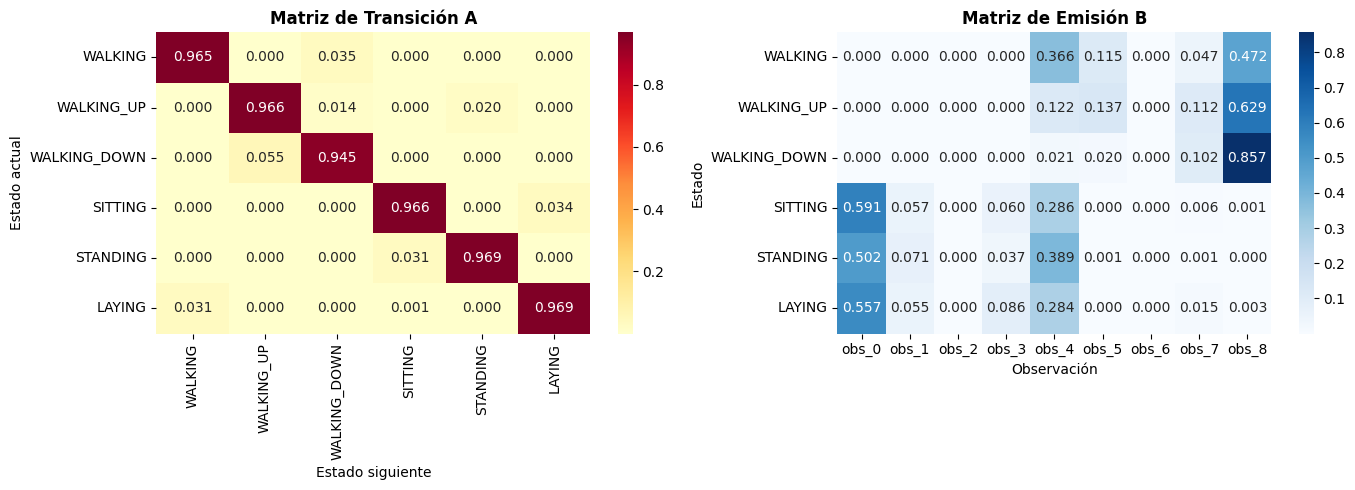

In [85]:
# ---- Visualizar matrices ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(A, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=activity_names, yticklabels=activity_names, ax=axes[0])
axes[0].set_title('Matriz de Transición A', fontweight='bold')
axes[0].set_xlabel('Estado siguiente')
axes[0].set_ylabel('Estado actual')

sns.heatmap(B, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=[f'obs_{i}' for i in range(N_OBS)],
            yticklabels=activity_names, ax=axes[1])
axes[1].set_title('Matriz de Emisión B', fontweight='bold')
axes[1].set_xlabel('Observación')
axes[1].set_ylabel('Estado')

plt.tight_layout()
plt.savefig('matrices_hmm.png', dpi=150, bbox_inches='tight')
plt.show()

In [86]:
# ---- Construir el modelo en hmmlearn con los parámetros estimados ----
from hmmlearn import hmm

model = hmm.CategoricalHMM(n_components=N_STATES, n_iter=1, init_params='')

# Cargar parámetros calculados manualmente
model.startprob_ = pi
model.transmat_  = A
model.emissionprob_ = B

print("Modelo HMM construido con parámetros manuales.")
print(f"  Nº estados:      {model.n_components}")
print(f"  Nº observaciones:{model.n_features}")
print(f"  pi suma a:       {model.startprob_.sum():.6f}")
print(f"  A filas suman a: {model.transmat_.sum(axis=1)}")
print(f"  B filas suman a: {model.emissionprob_.sum(axis=1)}")

Modelo HMM construido con parámetros manuales.
  Nº estados:      6
  Nº observaciones:None
  pi suma a:       1.000000
  A filas suman a: [1. 1. 1. 1. 1. 1.]
  B filas suman a: [1. 1. 1. 1. 1. 1.]


## C. Selección de subsecuencia y Forward-Backward

Seleccionamos una subsecuencia real del sujeto 1 de longitud ≥ 10.

In [87]:
# ---- Selección de subsecuencia real ----
# Usamos las primeras 15 observaciones del sujeto 1
SUBJECT_ID = 1
SEQ_START  = 0
SEQ_LEN    = 15

idx_subj = sequences_obs[SUBJECT_ID - 1]  # 0-indexed
states_subj = sequences_state[SUBJECT_ID - 1]

obs_subseq   = idx_subj[SEQ_START : SEQ_START + SEQ_LEN]
state_subseq = states_subj[SEQ_START : SEQ_START + SEQ_LEN]

print(f"Subsecuencia de observaciones (sujeto {SUBJECT_ID}, posiciones {SEQ_START}-{SEQ_START+SEQ_LEN-1}):")
print(obs_subseq)
print(f"\nEstados reales correspondientes:")
print([activity_names[s] for s in state_subseq])

# Formato requerido por hmmlearn: columna
obs_input = obs_subseq.reshape(-1, 1)

Subsecuencia de observaciones (sujeto 1, posiciones 0-14):
[3 0 0 0 0 0 0 0 0 0 0 0 0 0 4]

Estados reales correspondientes:
['STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING']


In [88]:
# ---- Forward-Backward ----
# hmmlearn expone las matrices alpha (forward) y beta (backward)
# mediante score_samples y métodos internos.
# Las calculamos manualmente para mayor claridad.

def forward(pi, A, B, obs):
    """Algoritmo Forward: devuelve alpha[t,s] = P(o_1..o_t, q_t=s)"""
    T = len(obs)
    S = len(pi)
    alpha = np.zeros((T, S))
    alpha[0] = pi * B[:, obs[0]]
    for t in range(1, T):
        alpha[t] = (alpha[t-1] @ A) * B[:, obs[t]]
    return alpha

def backward(A, B, obs):
    """Algoritmo Backward: devuelve beta[t,s] = P(o_t+1..o_T | q_t=s)"""
    T = len(obs)
    S = A.shape[0]
    beta = np.zeros((T, S))
    beta[T-1] = 1.0
    for t in range(T-2, -1, -1):
        beta[t] = A @ (B[:, obs[t+1]] * beta[t+1])
    return beta

alpha = forward(pi, A, B, obs_subseq)
beta  = backward(A, B, obs_subseq)

# Probabilidad de la secuencia observada
P_obs = alpha[-1].sum()
print(f"P(secuencia observada) = {P_obs:.6e}")

# Probabilidad a posteriori de cada estado en cada instante
# gamma[t, s] = P(q_t = s | O, modelo)
gamma = (alpha * beta)
gamma = gamma / gamma.sum(axis=1, keepdims=True)  # normalizar

print("\ngamma[t, s] = P(q_t=s | O) — primeras 5 filas:")
gamma_df = pd.DataFrame(gamma[:5], columns=activity_names)
gamma_df.index.name = 't'
print(gamma_df.round(4).to_string())

P(secuencia observada) = 2.884976e-06

gamma[t, s] = P(q_t=s | O) — primeras 5 filas:
   WALKING  WALKING_UP  WALKING_DOWN  SITTING  STANDING  LAYING
t                                                              
0      0.0         0.0           0.0   0.0000    1.0000  0.0000
1      0.0         0.0           0.0   0.1053    0.8947  0.0000
2      0.0         0.0           0.0   0.1922    0.8063  0.0015
3      0.0         0.0           0.0   0.2636    0.7321  0.0044
4      0.0         0.0           0.0   0.3215    0.6698  0.0086


In [89]:
# ---- 4 Consultas Forward-Backward ----

print("="*60)
print("CONSULTA 1: ¿Cuál es el estado más probable en t=0?")
t = 0
estado_map = np.argmax(gamma[t])
print(f"  Estado más probable en t={t}: {activity_names[estado_map]}")
print(f"  Probabilidades: { {activity_names[i]: round(gamma[t,i],4) for i in range(N_STATES)} }")
print(f"  Estado real:    {activity_names[state_subseq[t]]}")

print()
print("="*60)
print("CONSULTA 2: ¿Cuál es el estado más probable en t=5?")
t = 5
estado_map = np.argmax(gamma[t])
print(f"  Estado más probable en t={t}: {activity_names[estado_map]}")
print(f"  Probabilidades: { {activity_names[i]: round(gamma[t,i],4) for i in range(N_STATES)} }")
print(f"  Estado real:    {activity_names[state_subseq[t]]}")

print()
print("="*60)
print("CONSULTA 3: ¿Cuál es la probabilidad de LAYING en t=10?")
t = 10
estado_idx = activity_names.index('LAYING')
print(f"  P(q_10 = LAYING | O) = {gamma[t, estado_idx]:.4f}")
print(f"  Estado real en t={t}:   {activity_names[state_subseq[t]]}")

print()
print("="*60)
print("CONSULTA 4: ¿En qué instante es más probable estar WALKING?")
walk_idx = activity_names.index('WALKING')
t_max = np.argmax(gamma[:, walk_idx])
print(f"  Instante con mayor P(WALKING): t={t_max}")
print(f"  P(q_{t_max} = WALKING | O) = {gamma[t_max, walk_idx]:.4f}")
print(f"  Estado real en t={t_max}:       {activity_names[state_subseq[t_max]]}")

CONSULTA 1: ¿Cuál es el estado más probable en t=0?
  Estado más probable en t=0: STANDING
  Probabilidades: {'WALKING': np.float64(0.0), 'WALKING_UP': np.float64(0.0), 'WALKING_DOWN': np.float64(0.0), 'SITTING': np.float64(0.0), 'STANDING': np.float64(1.0), 'LAYING': np.float64(0.0)}
  Estado real:    STANDING

CONSULTA 2: ¿Cuál es el estado más probable en t=5?
  Estado más probable en t=5: STANDING
  Probabilidades: {'WALKING': np.float64(0.0), 'WALKING_UP': np.float64(0.0), 'WALKING_DOWN': np.float64(0.0), 'SITTING': np.float64(0.3681), 'STANDING': np.float64(0.6177), 'LAYING': np.float64(0.0142)}
  Estado real:    STANDING

CONSULTA 3: ¿Cuál es la probabilidad de LAYING en t=10?
  P(q_10 = LAYING | O) = 0.0610
  Estado real en t=10:   STANDING

CONSULTA 4: ¿En qué instante es más probable estar WALKING?
  Instante con mayor P(WALKING): t=14
  P(q_14 = WALKING | O) = 0.0041
  Estado real en t=14:       STANDING


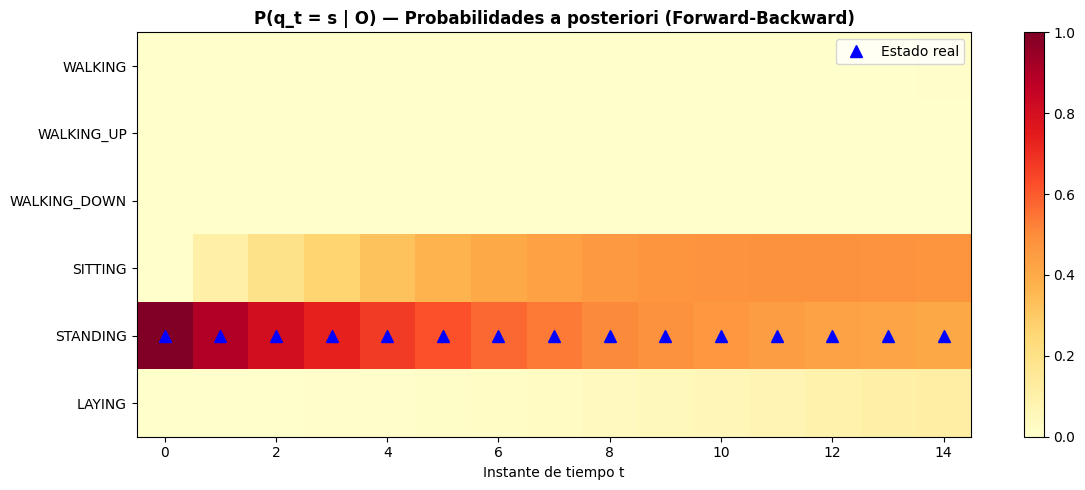

In [90]:
# ---- Visualización de gamma ----
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(gamma.T, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_yticks(range(N_STATES))
ax.set_yticklabels(activity_names)
ax.set_xlabel('Instante de tiempo t')
ax.set_title('P(q_t = s | O) — Probabilidades a posteriori (Forward-Backward)', fontweight='bold')
plt.colorbar(im, ax=ax)

# Marcar el estado real
for t, s in enumerate(state_subseq):
    ax.plot(t, s, 'b^', markersize=8)
ax.legend(['Estado real'], loc='upper right')

plt.tight_layout()
plt.savefig('forward_backward.png', dpi=150, bbox_inches='tight')
plt.show()

## D. Viterbi: secuencia de estados más probable

In [91]:
# ---- Viterbi manual ----
def viterbi(pi, A, B, obs):
    """
    Algoritmo de Viterbi.
    Retorna:
      best_path: secuencia de estados más probable
      best_prob: probabilidad del camino óptimo P(O, Q* | modelo)
    """
    T = len(obs)
    S = len(pi)
    delta = np.zeros((T, S))
    psi   = np.zeros((T, S), dtype=int)

    delta[0] = pi * B[:, obs[0]]
    psi[0]   = 0

    for t in range(1, T):
        for s in range(S):
            trans_prob = delta[t-1] * A[:, s]
            psi[t, s]   = np.argmax(trans_prob)
            delta[t, s] = np.max(trans_prob) * B[s, obs[t]]

    # Traceback
    best_path = np.zeros(T, dtype=int)
    best_path[T-1] = np.argmax(delta[T-1])
    best_prob = delta[T-1, best_path[T-1]]

    for t in range(T-2, -1, -1):
        best_path[t] = psi[t+1, best_path[t+1]]

    return best_path, best_prob

best_path, best_prob = viterbi(pi, A, B, obs_subseq)

print("=== Resultados Viterbi ===")
print(f"\nSecuencia de estados más probable:")
print([activity_names[s] for s in best_path])
print(f"\nEstados reales:")
print([activity_names[s] for s in state_subseq])
print(f"\nProbabilidad del camino óptimo P(O, Q* | modelo) = {best_prob:.6e}")

# Precisión de Viterbi vs estado real
accuracy = np.mean(best_path == state_subseq)
print(f"\nCoincidencia con estados reales: {accuracy*100:.1f}%")

=== Resultados Viterbi ===

Secuencia de estados más probable:
['STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING']

Estados reales:
['STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING']

Probabilidad del camino óptimo P(O, Q* | modelo) = 1.176119e-06

Coincidencia con estados reales: 100.0%


In [92]:
# ---- Probabilidad de la secuencia observada P(O | modelo) ----
# Usando hmmlearn para verificar
log_prob_hmmlearn = model.score(obs_input)
P_obs_hmmlearn = np.exp(log_prob_hmmlearn)

print(f"P(O | modelo) — manual (forward):   {P_obs:.6e}")
print(f"P(O | modelo) — hmmlearn score:     {P_obs_hmmlearn:.6e}")
print(f"Log-probabilidad (hmmlearn):         {log_prob_hmmlearn:.4f}")

P(O | modelo) — manual (forward):   2.884976e-06
P(O | modelo) — hmmlearn score:     2.884976e-06
Log-probabilidad (hmmlearn):         -12.7560


In [93]:
# ---- Verificación Viterbi con hmmlearn ----
log_prob_vit, viterbi_states_hmmlearn = model.decode(obs_input, algorithm='viterbi')

print("Viterbi hmmlearn:")
print([activity_names[s] for s in viterbi_states_hmmlearn])
print(f"Log-prob Viterbi (hmmlearn): {log_prob_vit:.4f}")
print(f"P(O, Q*) hmmlearn: {np.exp(log_prob_vit):.6e}")

Viterbi hmmlearn:
['STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING', 'STANDING']
Log-prob Viterbi (hmmlearn): -13.6533
P(O, Q*) hmmlearn: 1.176119e-06


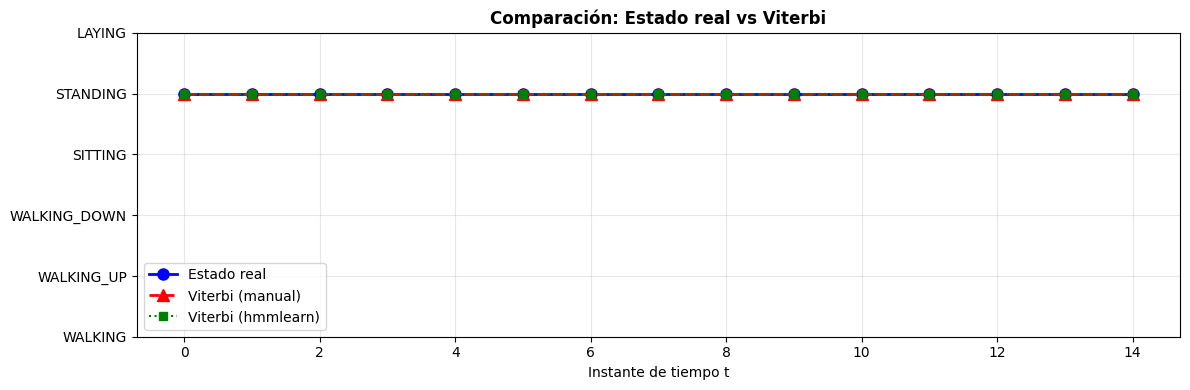

In [94]:
# ---- Visualización comparativa ----
fig, ax = plt.subplots(figsize=(12, 4))
t_range = range(SEQ_LEN)

ax.plot(t_range, state_subseq, 'bo-', label='Estado real', linewidth=2, markersize=8)
ax.plot(t_range, best_path,    'r^--', label='Viterbi (manual)', linewidth=2, markersize=8)
ax.plot(t_range, viterbi_states_hmmlearn, 'gs:', label='Viterbi (hmmlearn)', linewidth=1.5, markersize=6)

ax.set_yticks(range(N_STATES))
ax.set_yticklabels(activity_names)
ax.set_xlabel('Instante de tiempo t')
ax.set_title('Comparación: Estado real vs Viterbi', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('viterbi_comparacion.png', dpi=150, bbox_inches='tight')
plt.show()

## E. Análisis e interpretación de resultados

> 

**Análisis de la discretización**

Los umbrales obtenidos fueron $I_{acc} = -0.9705$ y $-0.2686$, e $I_{gyro} = -0.9636$ y $-0.4115$. Que sean negativos es coherente con que los índices combinan magnitudes normalizadas que en reposo tienden a valores bajos. La distribución muestra que las observaciones dominantes son obs_0 y obs_8, reflejando la separación natural entre actividades estáticas y dinámicas.

Las combinaciones obs_2 y obs_6 tienen 0 ocurrencias, lo cual es fisicamente razonables, ya que indican alta aceleración y bajo giro no ocurren en la práctica, y sus probabilidades nulas están manejadas por el suavizado de Laplace.

**Análisis matriz de transición A:**

Todas las actividades muestran una probablidad de autotransición muy alta. Esto nos refleja que las actividades humanas tienden a ser persistentes en el tiempo.

Ahora, existe una clara separación entre actividades estáticas y dinámicas. Casi no hay transición directas entre actividades de movimiento y actividades estáticas, excepto en algunos casos como **LAYING** y **WALKING**

**Análisis matriz de emisión B:**

Cada actividad tiene un perfil de emisión único. Las actividades de movimiento emiten predominantemente las obs_8 que son la aceleración y giros altos, con probabiliadades de hasta 0.8570 para bajar escaleras.

Por otro lado las actividades estáticas emiten mayoritariamente la obs_0 de aceleración y giros bajos, lo cual es coherente con la falta de movimiento del sensor.

**Análisis Forward-Backward y Viterbi:**

En la visulización de probabilidades a posteriori, podemos observar que el modelo asigna una probabilidad cercana a 1 al estado correcto durante periodos de estabilidad. Las diferencias menores ocurren generalmente en algunos instantes de transcicion donde las observaciones son confusas.

Para las consultas, la consulta 1, el modelo asigna probabilidad 1.0 a **STANDING** coincidiendo exactamento con el estado real. Esto refleja que en el instante inicial, la observación que se emite es altamente característica de esta actividad estática, lo que permite al modelo identificarla con certeza absoluta.

En la segunda consulta el estado más probable sigue siendo **STANDING**, aunque ahora aparece vacilación hacia **SITTING** y levemente hacia **LAYING**. El modelo sigue estando correcto, pero con menor certeza sobre t=0.

La probabilidad de **LAYING** en t=10 para la consulta 3 es del 0.061, siendo **STANDING** el estado real. EL modelo no confunde esta observación con **LAYING**, lo que es coherente, aunque ambas son actividades estáticas.

Por último el instante con mayor probabilidad de **WALKIN** es t=14, siendo el estado real **STANDING** en toda la subsecuencia. Esta probabilidad extremadamente baja confirma que ninguna observación de la subsecuencia analizada es característica de actvidades dinámicas.

La secuencia de estados más probable calculada por Viterbi tuvo una coincidencia del 100% con los estados reales en la sub-secuencia de preuba analizada.

La probabilidad del camino óptimo es inferior a la probabilidad total de observación. Que el camino óptimo represente aproximadamente el 40% de la probabilidad total indica que, aunque hay otros caminos posibles, el que identificó Viterbi es claramente el dominante y el modelo tiene alta confianza en él.

Finalmente los resultados manuales coinciden con los de la libreria hmmlearn.